<a href="https://colab.research.google.com/github/Shaman2320/QM640_Capstone_BuildingEnergyPerfromance/blob/main/cbecs_eda_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CBECS 2018 Building Energy Performance: Data Inspection, Cleaning, and EDA

This notebook implements the data preparation and exploratory analysis stage described in the interim report. It runs in four parts:

1. **Data inspection** — confirm shape, types, and missingness before any values are changed
2. **Data cleaning** — encode ordinal variables correctly, recode structurally missing HVAC fields, exclude undefined-EUI records, and derive EUI
3. **Univariate EDA** — one variable at a time: distributions, summary statistics, frequency tables
4. **Bivariate EDA** — each predictor against log site EUI: correlations, scatterplots, grouped boxplots

Every plot is written to `output/figures/` and every summary table to `output/tables/` as a CSV, in addition to rendering inline, so individual figures and tables can be pasted into the interim or final report without re-running the analysis.

**Using this notebook from the project's GitHub repository.** The repository ([Shaman2320/QM640_Capstone_BuildingEnergyPerfromance](https://github.com/Shaman2320/QM640_Capstone_BuildingEnergyPerfromance)) keeps the raw microdata at `data/raw/cbecs2018_final_public.csv`, notebooks and scripts under `src/`, and generated artifacts under `output/`. By default this notebook reads the CSV directly from GitHub via its `raw.githubusercontent.com` URL, so it runs anywhere (including Colab) without cloning. To run against a local clone instead, set `USE_GITHUB_RAW = False` and run from the repository root so the relative path in `INPUT_CSV` resolves.

## 1. Setup and Configuration

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ---- Data source ----------------------------------------------------------
# Default: read the CSV straight from the project repository on GitHub.
USE_GITHUB_RAW = True
GITHUB_RAW_CSV_URL = "https://raw.githubusercontent.com/Shaman2320/QM640_Capstone_BuildingEnergyPerfromance/main/data/raw/cbecs2018_final_public.csv"

# Fallback: local path relative to the repository root, used when
# USE_GITHUB_RAW = False and the repo has been cloned.
INPUT_CSV = "data/raw/cbecs2018_final_public.csv"

# ---- Output locations -----------------------------------------------------
# Matches the repository's output/ folder so generated artifacts can be
# committed alongside the data and code.
FIG_DIR = "output/figures"
TAB_DIR = "output/tables"

# The seventeen analysis variables specified in the synopsis (Table 2),
# grouped by role so the cleaning and EDA steps below can address each
# group with the treatment it actually needs.
ID_VARS = ["PUBID"]
CONTINUOUS_VARS = ["SQFT", "FLCEILHT", "WKHRS", "NWKER", "HDD65", "CDD65"]
ORDINAL_VARS = ["NFLOOR", "YRCONC", "GLSSPC"]
NOMINAL_VARS = ["PBA", "WLCNS", "RFCNS", "MAINHT", "MAINCL", "OPEN24"]
WEIGHT_VAR = "FINALWT"
FUEL_VAR = "MFBTU"

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}/")
print(f"Tables will be saved to:  {TAB_DIR}/")

Figures will be saved to: output/figures/
Tables will be saved to:  output/tables/


## 2. Data Inspection

### 2.1 Load Raw Data and Inspect Structure

Before any values are touched, confirm the raw file's shape, dtypes, and missingness. This is the check that catches a bad download or a truncated read before it silently propagates into the cleaned data.

In [14]:
raw = pd.read_csv(GITHUB_RAW_CSV_URL if USE_GITHUB_RAW else INPUT_CSV)
print(f"Raw shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
raw.head()

Raw shape: 6436 rows x 1249 columns


,PUBID,REGION,CENDIV,PBA,PUBCLIM,SQFT,SQFTC,WLCNS,RFCNS,RFCOOL,...,ZMFBTU,ZMFEXP,ZELCNS,ZELEXP,ZNGCNS,ZNGEXP,ZFKCNS,ZFKEXP,ZDHBTU,ZDHEXP
0,1,3,5,2,3,210000,8,1,4,2,...,0,0,0,0,9,9,1,1,0,0
1,2,4,9,2,4,28000,5,1,6,1,...,0,0,0,0,0,0,9,9,9,9
2,3,3,5,8,4,2100,2,1,4,2,...,0,0,0,0,9,9,9,9,9,9
3,4,3,7,5,5,240000,8,2,6,1,...,0,0,0,0,1,1,9,9,9,9
4,5,1,2,5,3,295000,8,3,6,2,...,0,0,0,0,0,0,9,9,9,9


**Observation.** The file loads at 6,436 rows by 1,249 columns, matching the dimensions EIA documents for the December 2022 revision of the microdata, so the correct release was retrieved and nothing was truncated in transit. The first rows show the expected one-building-per-record layout keyed by PUBID.

In [15]:
analysis_cols = ID_VARS + CONTINUOUS_VARS + ORDINAL_VARS + NOMINAL_VARS + [WEIGHT_VAR, FUEL_VAR]
missing_present = [c for c in analysis_cols if c not in raw.columns]
if missing_present:
    raise KeyError(f"Expected analysis columns not found in file: {missing_present}")

subset = raw[analysis_cols]
inspection = pd.DataFrame({
    "dtype": subset.dtypes.astype(str),
    "n_non_null": subset.notna().sum(),
    "n_missing": subset.isna().sum(),
    "pct_missing": (subset.isna().mean() * 100).round(2),
    "n_unique": subset.nunique(),
})
inspection.to_csv(os.path.join(TAB_DIR, "01_raw_variable_inspection.csv"))
inspection

,dtype,n_non_null,n_missing,pct_missing,n_unique
PUBID,int64,6436,0,0.00,6436
SQFT,int64,6436,0,0.00,410
FLCEILHT,int64,6436,0,0.00,41
WKHRS,int64,6436,0,0.00,143
NWKER,int64,6436,0,0.00,356
HDD65,int64,6436,0,0.00,4407
CDD65,int64,6436,0,0.00,2917
NFLOOR,int64,6436,0,0.00,11
YRCONC,int64,6436,0,0.00,8
GLSSPC,int64,6436,0,0.00,6


**Observation.** Of the seventeen analysis variables, only three carry any missingness in the raw file: MAINHT (429 records, 6.67 percent), MAINCL (456, 7.09 percent), and MFBTU (79, 1.23 percent). Everything else is fully populated, which reflects EIA's imputation of most fields before public release. Each of the three gaps gets a deliberate treatment in the cleaning step below rather than a default drop.

### 2.2 Validate Sampling Weights

Reconstruct the weighted population total from `FINALWT` and compare it against the EIA-published estimate of 5.9 million commercial buildings. A large discrepancy here would indicate a merge error or a truncated read, so this check runs before any records are dropped.

In [16]:
weighted_buildings_millions = raw[WEIGHT_VAR].sum() / 1_000_000
weighted_floorspace_millions_sqft = (raw[WEIGHT_VAR] * raw["SQFT"]).sum() / 1_000_000

weight_summary = pd.DataFrame({
    "metric": ["weighted_buildings_millions", "weighted_floorspace_million_sqft"],
    "value": [round(weighted_buildings_millions, 3), round(weighted_floorspace_millions_sqft, 0)],
})
weight_summary.to_csv(os.path.join(TAB_DIR, "02_weight_validation.csv"), index=False)
weight_summary

,metric,value
0,weighted_buildings_millions,5.918
1,weighted_floorspace_million_sqft,96527.000


**Observation.** Summing FINALWT reconstructs 5.918 million buildings and 96,527 million square feet of floorspace, within 0.3 percent of the EIA-published totals. Because FINALWT is calibrated to reproduce those totals, this agreement is a necessary check that no records were lost or misjoined during ingestion, and it passes before any cleaning has altered the file.

## 3. Data Cleaning

The cleaning steps run in the order that avoids inconsistent intermediate states: exclude undefined-EUI records first, then recode structural missingness, then fix variable types, then derive EUI.

In [17]:
df = raw.copy()

# Exclude buildings with no reported major-fuel consumption: EUI is
# undefined for these records, not merely missing, so they cannot be
# imputed and must be dropped before EUI is computed.
n_before = len(df)
df = df[df[FUEL_VAR].notna()].copy()
print(f"Dropped {n_before - len(df)} records with undefined MFBTU; {len(df)} remain.")

# MAINHT and MAINCL missingness is treated as structural rather than
# random: a blank main heating/cooling type most plausibly means the
# building has no primary system, which is itself informative for
# small, naturally ventilated, or single-purpose buildings.
df["MAINHT"] = df["MAINHT"].fillna(0)
df["MAINCL"] = df["MAINCL"].fillna(0)

# NFLOOR and GLSSPC are ordered categories, not interval-scaled integers:
# NFLOOR groups tall buildings into codes 994/995 rather than reporting an
# exact floor count, and GLSSPC reports six glazing bands rather than an
# exact percentage. Encoding them as ordered categoricals keeps their
# sequence for models that use it, without implying equal spacing between
# codes that the source data does not support.
for col in ORDINAL_VARS:
    ordered_categories = sorted(df[col].dropna().unique())
    df[col] = pd.Categorical(df[col], categories=ordered_categories, ordered=True)

# Nominal categoricals: cast to pandas category dtype so downstream
# group-by and plotting calls treat them as labels, not numbers.
for col in NOMINAL_VARS:
    df[col] = df[col].astype("category")

# Derive the response variable. EUI is undefined for zero or negative
# floor area, which should not occur in CBECS but is guarded against
# explicitly rather than allowed to produce a silent inf or NaN.
if (df["SQFT"] <= 0).any():
    bad = (df["SQFT"] <= 0).sum()
    raise ValueError(f"{bad} records have non-positive SQFT; investigate before computing EUI.")

df["EUI"] = df[FUEL_VAR] / df["SQFT"]
df["log_EUI"] = np.log(df["EUI"])

print(f"Cleaned analysis sample: {len(df)} buildings")
df.head()

Dropped 79 records with undefined MFBTU; 6357 remain.
Cleaned analysis sample: 6357 buildings


,PUBID,REGION,CENDIV,PBA,PUBCLIM,SQFT,SQFTC,WLCNS,RFCNS,RFCOOL,...,ZELCNS,ZELEXP,ZNGCNS,ZNGEXP,ZFKCNS,ZFKEXP,ZDHBTU,ZDHEXP,EUI,log_EUI
0,1,3,5,2,3,210000,8,1,4,2,...,0,0,9,9,1,1,0,0,141.557867,4.952709
1,2,4,9,2,4,28000,5,1,6,1,...,0,0,0,0,9,9,9,9,61.809107,4.124051
2,3,3,5,8,4,2100,2,1,4,2,...,0,0,9,9,9,9,9,9,24.946190,3.216721
3,4,3,7,5,5,240000,8,2,6,1,...,0,0,1,1,9,9,9,9,13.274062,2.585812
4,5,1,2,5,3,295000,8,3,6,2,...,0,0,0,0,9,9,9,9,15.854268,2.763439


**Observation.** Cleaning removes exactly the 79 records with undefined MFBTU and nothing else, leaving the 6,357-building analysis sample the synopsis anticipated. The MAINHT and MAINCL recodes keep those buildings in the sample rather than imputing a system type they most plausibly do not have, and the ordinal encodings stop NFLOOR's 994/995 codes and GLSSPC's glazing bands from masquerading as interval-scaled numbers in the models that follow.

## 4. Univariate Exploratory Data Analysis

### 4.1 Continuous Variables

For each continuous predictor and for EUI itself (raw and logged), a histogram, a boxplot, and a row of summary statistics are produced. Skewness is reported explicitly so the case for log-transforming EUI is documented with a number rather than asserted by eye.

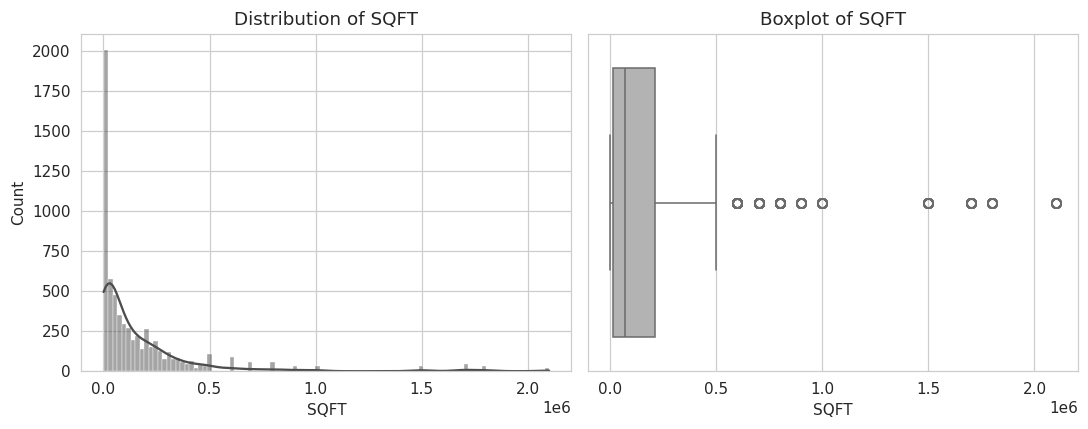

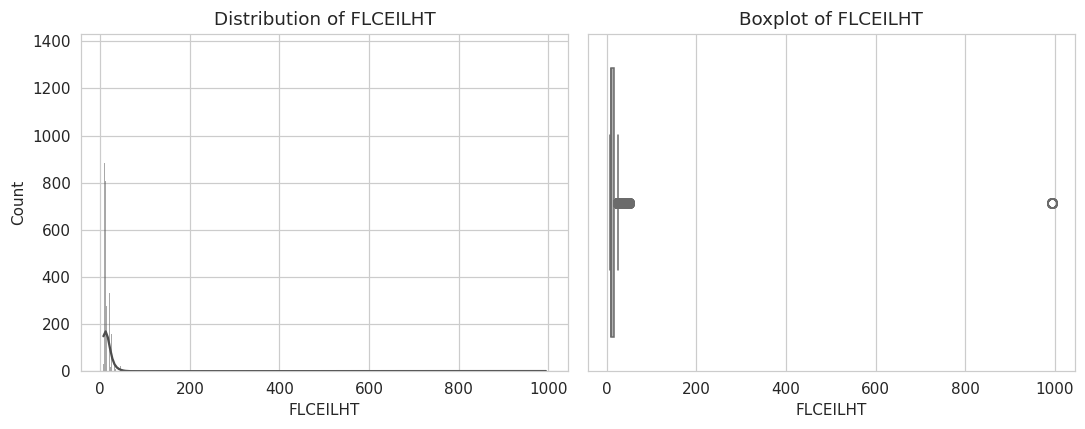

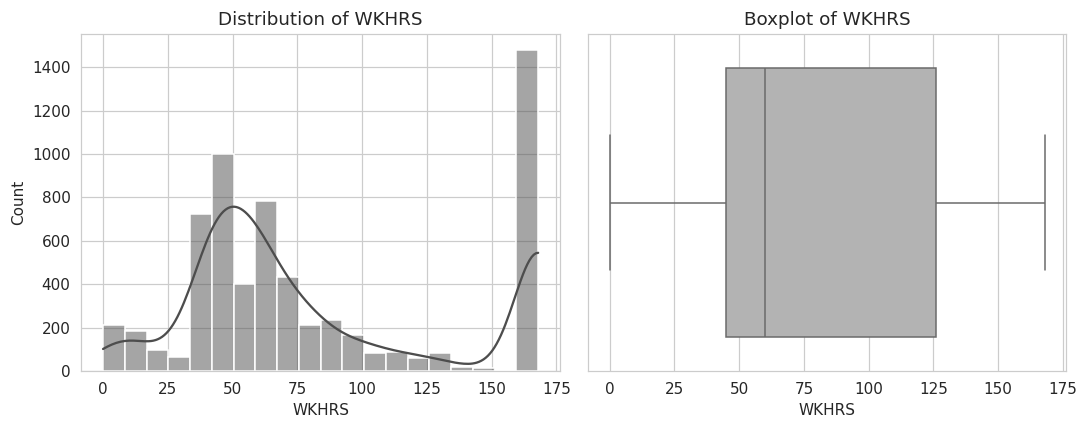

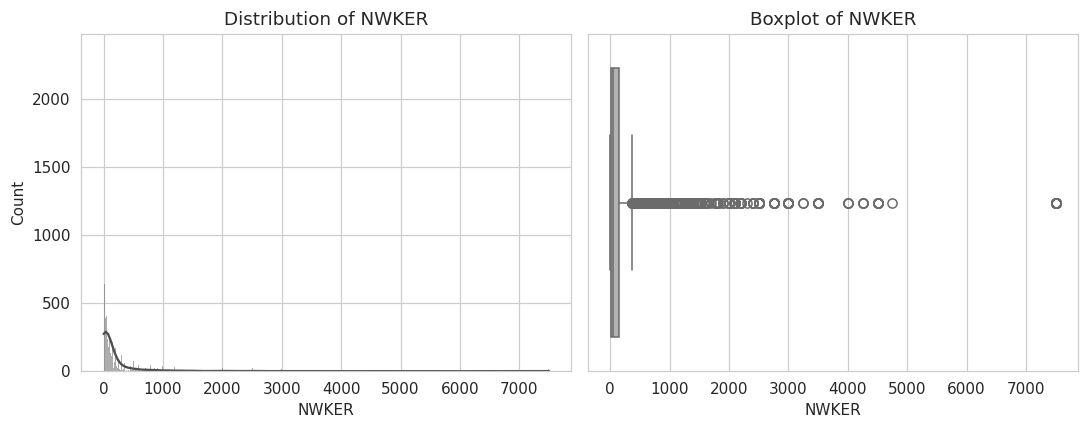

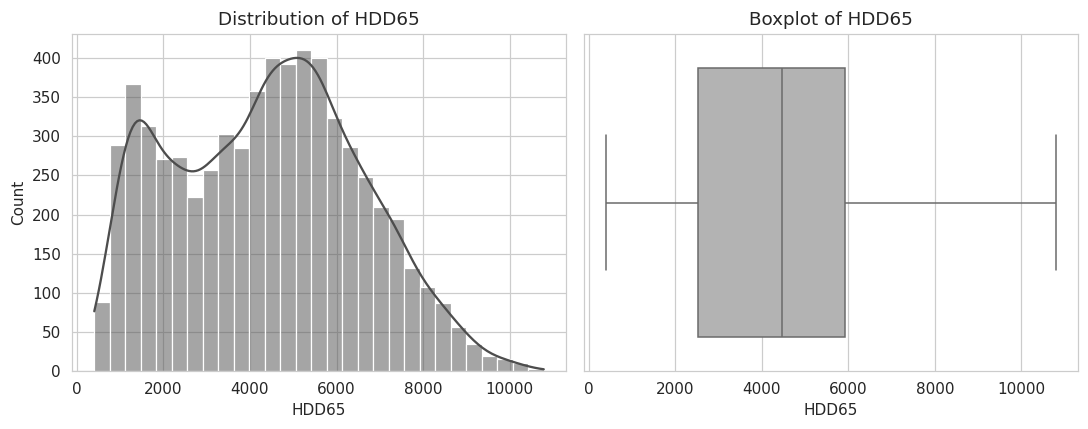

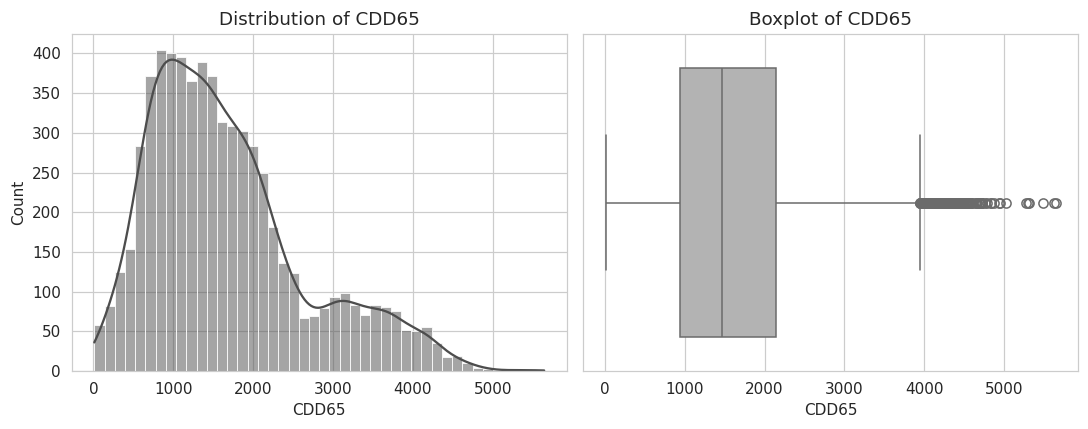

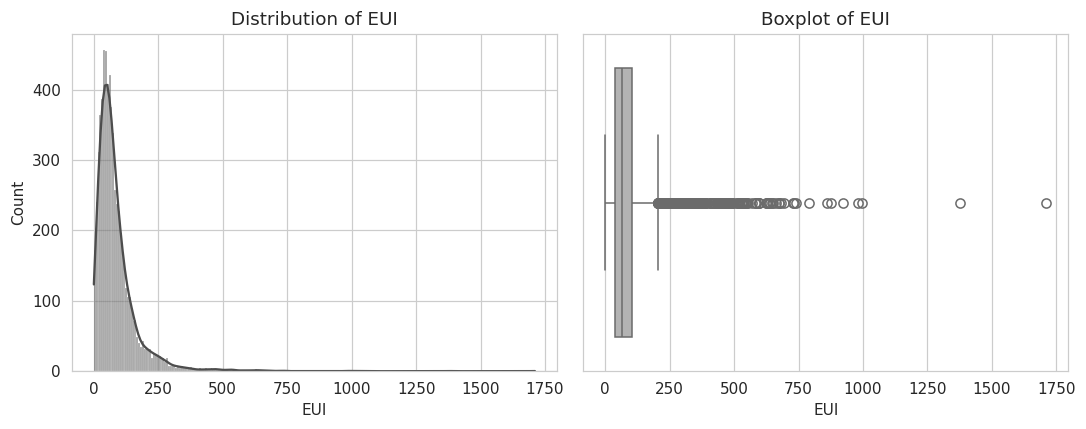

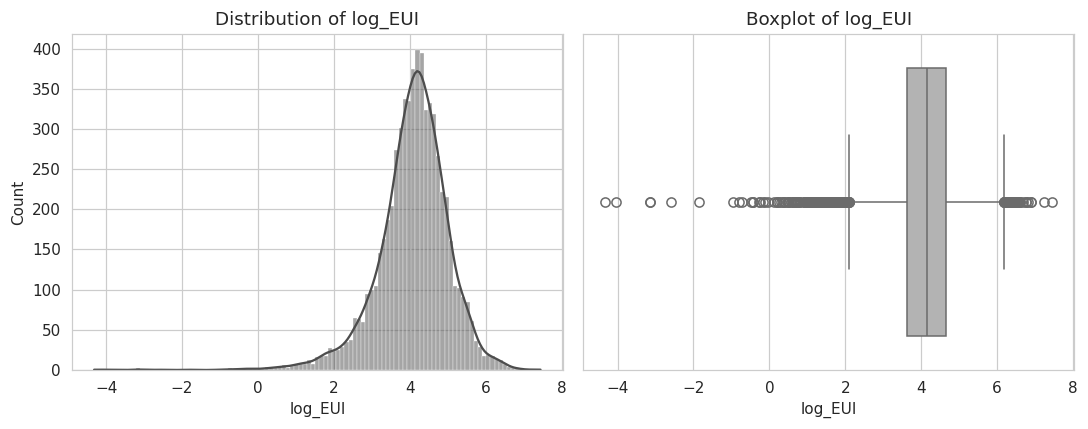

,variable,n,mean,median,sd,min,max,skewness,kurtosis
0,SQFT,6357,170994.197,72000.000,286317.523,1001.000,2100000.000,3.762,17.369
1,FLCEILHT,6357,15.847,10.000,46.561,7.000,995.000,20.490,427.837
2,WKHRS,6357,83.237,60.000,52.434,0.000,168.000,0.642,-0.964
3,NWKER,6357,202.378,40.000,566.757,0.000,7500.000,7.324,74.205
4,HDD65,6357,4380.983,4472.000,2158.640,402.000,10790.000,0.127,-0.761
5,CDD65,6357,1676.525,1471.000,987.142,10.000,5643.000,0.943,0.420
6,EUI,6357,86.043,64.183,87.159,0.013,1710.839,4.556,42.541
7,log_EUI,6357,4.085,4.162,0.937,-4.317,7.445,-1.114,5.223


In [18]:
vars_to_profile = CONTINUOUS_VARS + ["EUI", "log_EUI"]
rows = []

for col in vars_to_profile:
    series = df[col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(series, kde=True, ax=axes[0], color="0.3")
    axes[0].set_title(f"Distribution of {col}")
    sns.boxplot(x=series, ax=axes[1], color="0.7")
    axes[1].set_title(f"Boxplot of {col}")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"03_univariate_{col}.png"))
    plt.show()

    rows.append({
        "variable": col,
        "n": series.shape[0],
        "mean": series.mean(),
        "median": series.median(),
        "sd": series.std(),
        "min": series.min(),
        "max": series.max(),
        "skewness": stats.skew(series),
        "kurtosis": stats.kurtosis(series),
    })

continuous_summary = pd.DataFrame(rows).round(3)
continuous_summary.to_csv(os.path.join(TAB_DIR, "03_univariate_continuous_summary.csv"), index=False)
continuous_summary

**Observation.** Two results here matter for the modelling ahead. Raw EUI is heavily right-skewed (skewness 4.556, excess kurtosis 42.541), and the log transform brings those to −1.114 and 5.223: much closer to symmetric, but with tails still heavier than a normal distribution, which sets the expectation against which RQ1's residual diagnostics should be read. FLCEILHT is the anomaly: skewness of 20.490 and kurtosis of 427.837 sit far beyond every other variable and trace to fourteen records carrying 995, the CBECS top-code for more than 50 feet rather than a literal height. Excluding those fourteen drops the two statistics to 2.183 and 5.298, in line with the rest of the table, so the top-code needs recoding or exclusion before FLCEILHT enters a regression as a continuous term.

### 4.2 Categorical Variables

For each categorical or ordinal predictor, the unweighted frequency, the survey-weighted frequency (using `FINALWT`), and a bar chart of the weighted shares are produced. Weighted and unweighted frequencies are reported side by side because CBECS's stratified design means the two can diverge, and a variable that looks balanced in raw counts is not necessarily balanced in the population it represents.

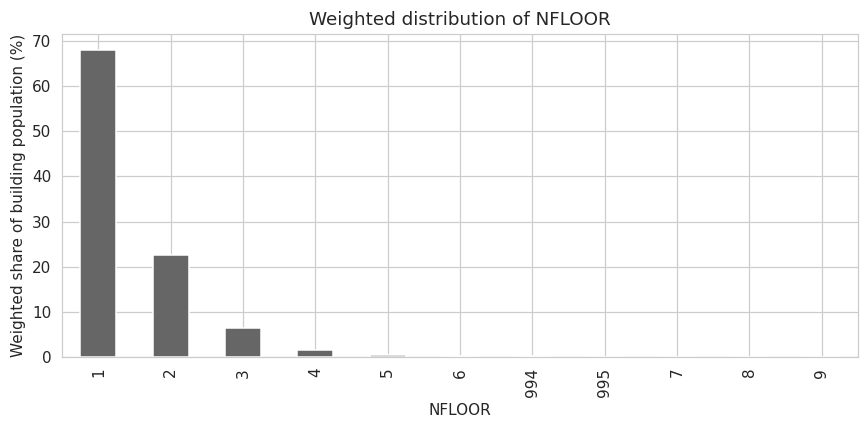

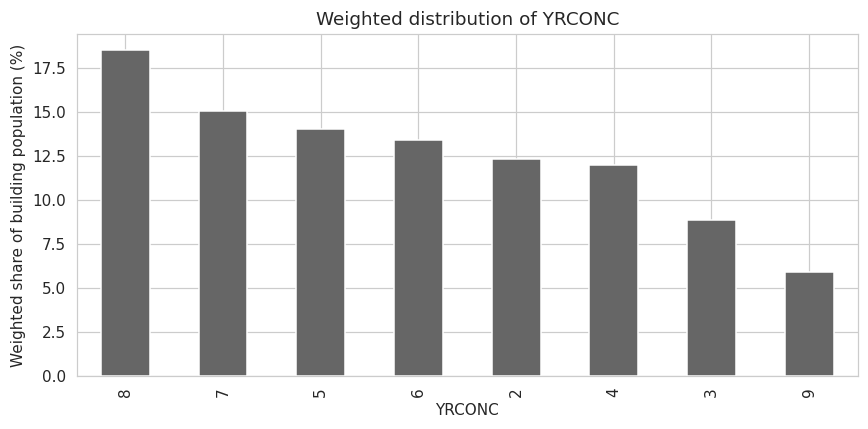

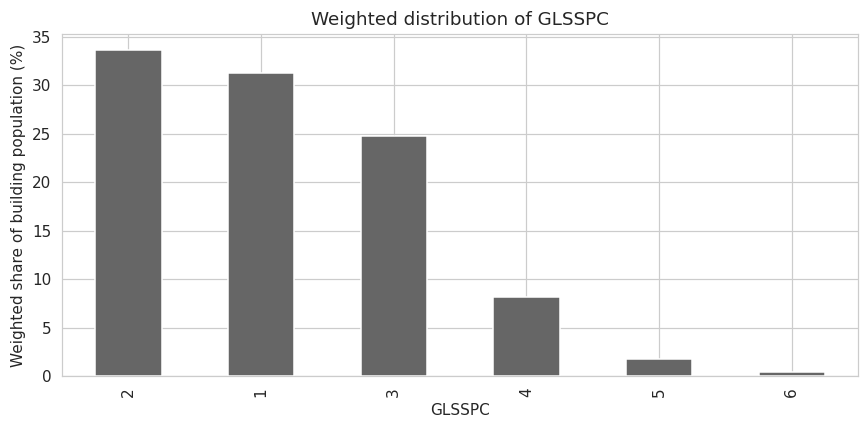

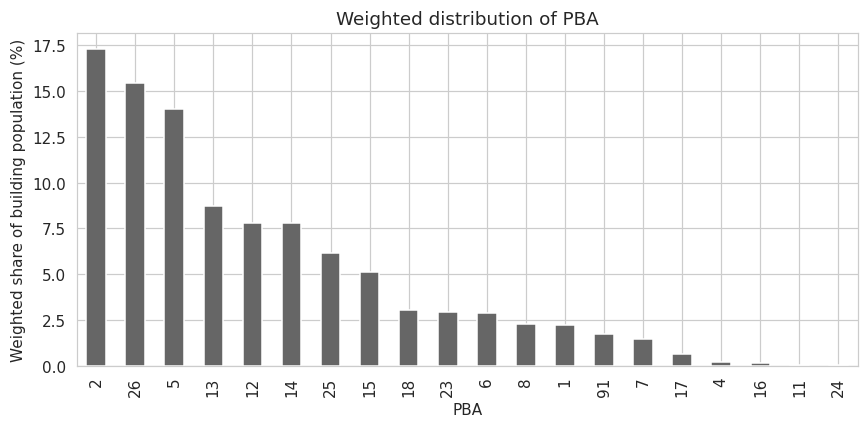

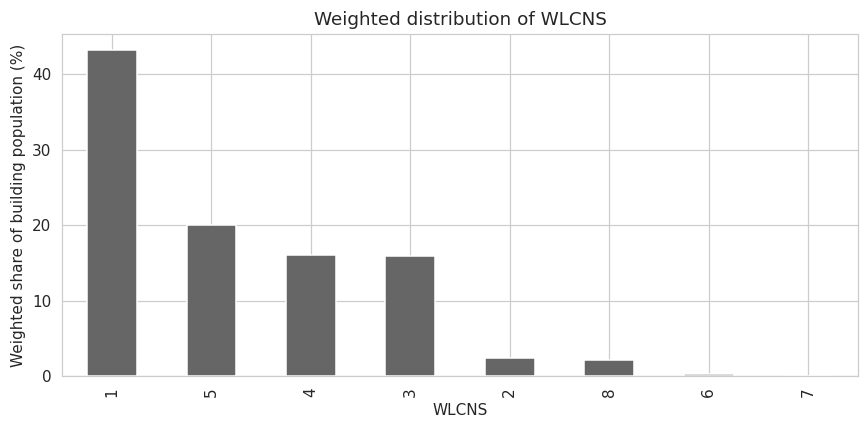

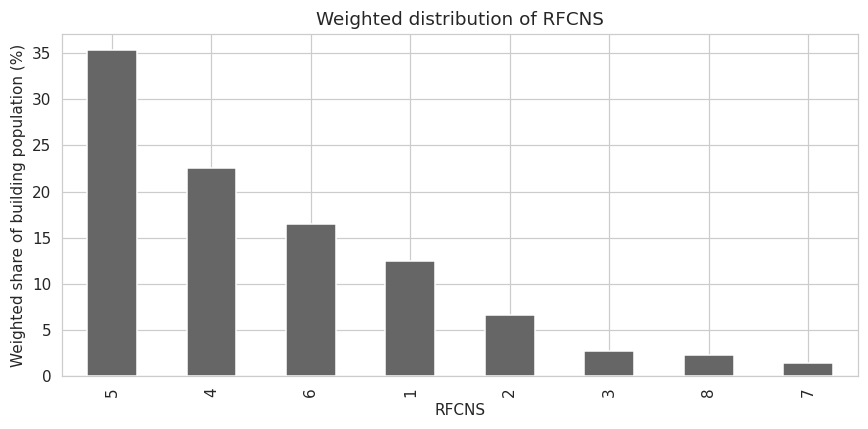

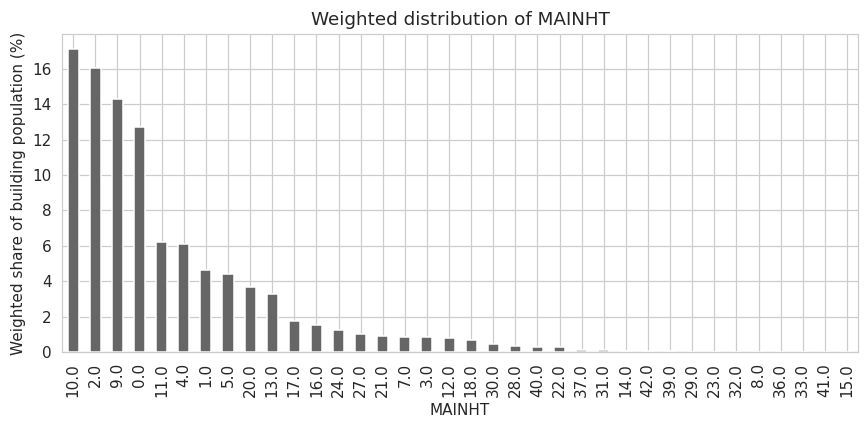

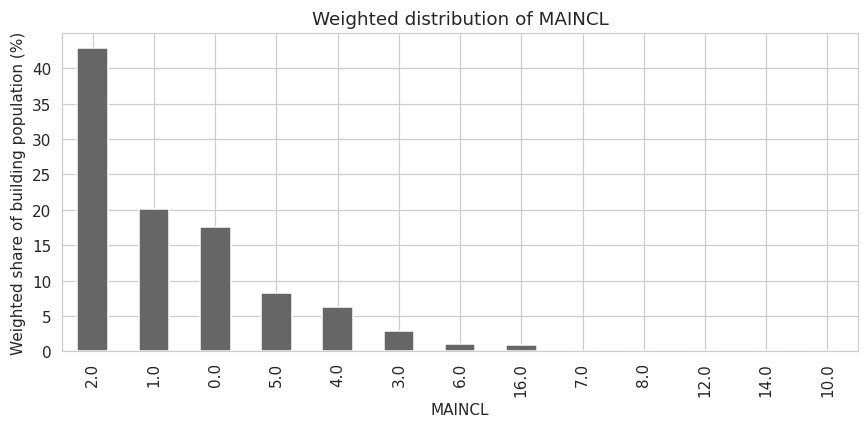

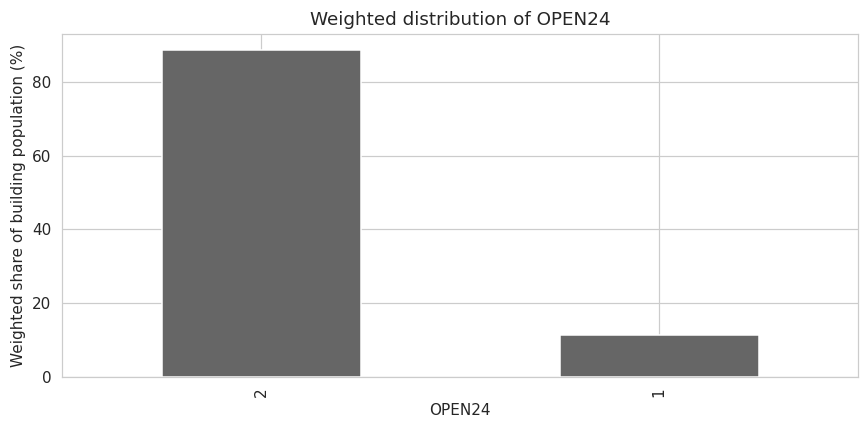

,n_unweighted,weighted_buildings,pct_unweighted,pct_weighted
PBA,,,,
2,1329,970302.56,20.91,17.29
26,349,866297.67,5.49,15.43
5,712,788208.58,11.20,14.04
13,481,488199.37,7.57,8.70
12,271,438605.53,4.26,7.81
14,936,437485.53,14.72,7.79
25,338,346271.63,5.32,6.17
15,218,286466.91,3.43,5.10
18,418,169453.04,6.58,3.02


In [19]:
vars_to_profile = ORDINAL_VARS + NOMINAL_VARS
categorical_tables = {}

for col in vars_to_profile:
    counts = df.groupby(col, observed=True).size().rename("n_unweighted")
    weighted = df.groupby(col, observed=True)[WEIGHT_VAR].sum().rename("weighted_buildings")
    freq = pd.concat([counts, weighted], axis=1)
    freq["pct_unweighted"] = (freq["n_unweighted"] / freq["n_unweighted"].sum() * 100).round(2)
    freq["pct_weighted"] = (freq["weighted_buildings"] / freq["weighted_buildings"].sum() * 100).round(2)
    freq = freq.sort_values("weighted_buildings", ascending=False)
    freq.to_csv(os.path.join(TAB_DIR, f"04_frequency_{col}.csv"))
    categorical_tables[col] = freq

    fig, ax = plt.subplots(figsize=(8, 4))
    freq["pct_weighted"].plot(kind="bar", ax=ax, color="0.4")
    ax.set_ylabel("Weighted share of building population (%)")
    ax.set_title(f"Weighted distribution of {col}")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"04_univariate_{col}.png"))
    plt.show()

categorical_tables["PBA"]

**Observation.** The weighted and unweighted shares diverge exactly the way a stratified sample should. Reading the PBA codes on the chart: offices (code 2) lead the weighted population at 17.29 percent while making up 20.91 percent of raw records, service buildings (code 26) expand from 5.49 percent of the sample to 15.43 percent of the population, and nonrefrigerated warehouses (code 5) hold 14.04 percent weighted. That near-threefold expansion for service buildings means they are under-sampled relative to their population share, and it is the concrete reason FINALWT rather than raw counts must anchor every activity-level statement, including RQ2's two-way ANOVA with activity.

## 5. Bivariate Exploratory Data Analysis

### 5.1 Correlation Matrix

Correlation among continuous predictors and log EUI is the first, cheapest check for multicollinearity: pairs with |r| above about 0.8 here are flagged for a VIF check once the regression is fit, rather than waiting for the regression diagnostics to surface them.

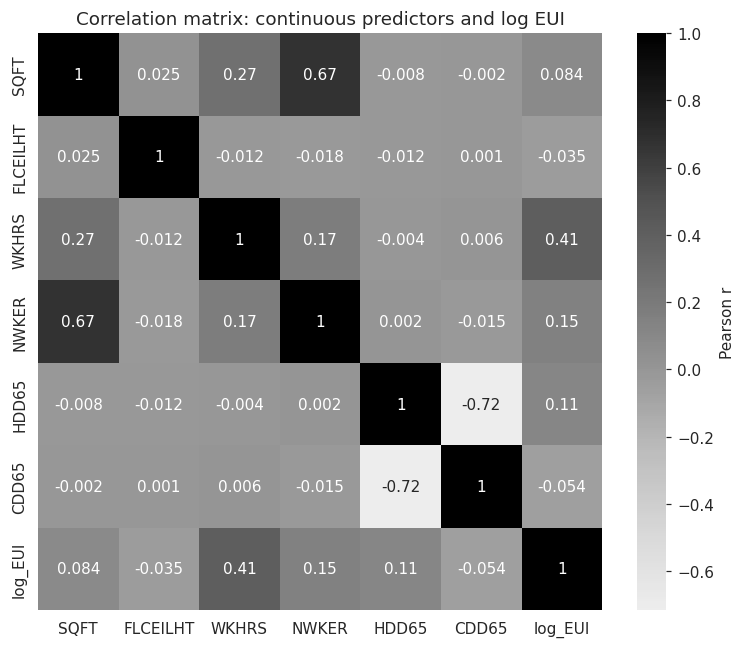

,SQFT,FLCEILHT,WKHRS,NWKER,HDD65,CDD65,log_EUI
SQFT,1.000,0.025,0.270,0.674,-0.008,-0.002,0.084
FLCEILHT,0.025,1.000,-0.012,-0.018,-0.012,0.001,-0.035
WKHRS,0.270,-0.012,1.000,0.174,-0.004,0.006,0.406
NWKER,0.674,-0.018,0.174,1.000,0.002,-0.015,0.149
HDD65,-0.008,-0.012,-0.004,0.002,1.000,-0.716,0.114
CDD65,-0.002,0.001,0.006,-0.015,-0.716,1.000,-0.054
log_EUI,0.084,-0.035,0.406,0.149,0.114,-0.054,1.000


In [20]:
cols = CONTINUOUS_VARS + ["log_EUI"]
corr = df[cols].corr(method="pearson").round(3)
corr.to_csv(os.path.join(TAB_DIR, "05_correlation_matrix.csv"))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap="Greys", center=0, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("Correlation matrix: continuous predictors and log EUI")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "05_correlation_heatmap.png"))
plt.show()

corr

**Observation.** Weekly operating hours is the strongest continuous correlate of log EUI at r = 0.406, well ahead of workers (0.149), heating degree days (0.114), and floor area (0.084), an early signal that operational intensity rather than size or climate will likely lead RQ1's ranking. Two pairs deserve collinearity attention once the regression is fit: HDD65 with CDD65 at r = −0.716, expected since cold locations accumulate few cooling degree days, and SQFT with NWKER at 0.674, since larger buildings employ more people. Both sit under the 0.8 screening threshold but close enough to justify a VIF check rather than waiting for unstable coefficients to reveal the problem.

### 5.2 Continuous Predictors vs. Log EUI

A scatterplot of log EUI against each continuous predictor with a fitted linear trend shows whether a relationship is clearly non-linear (and might need a transformation or a spline term) before RQ1's linear model is fit, rather than being discovered only through a residual plot afterward.

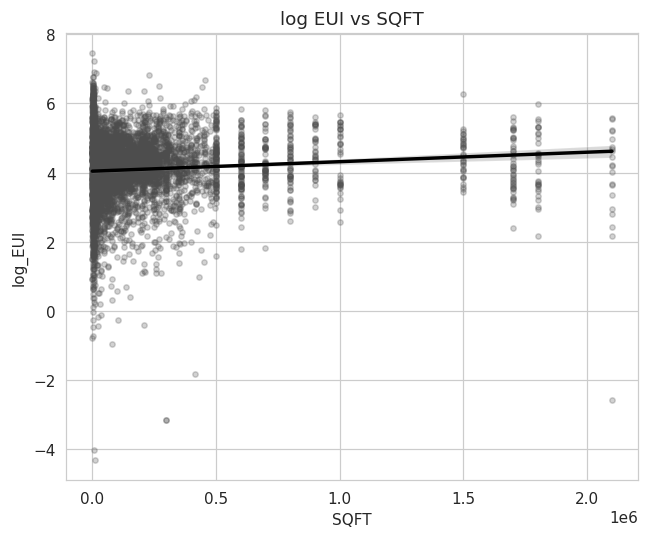

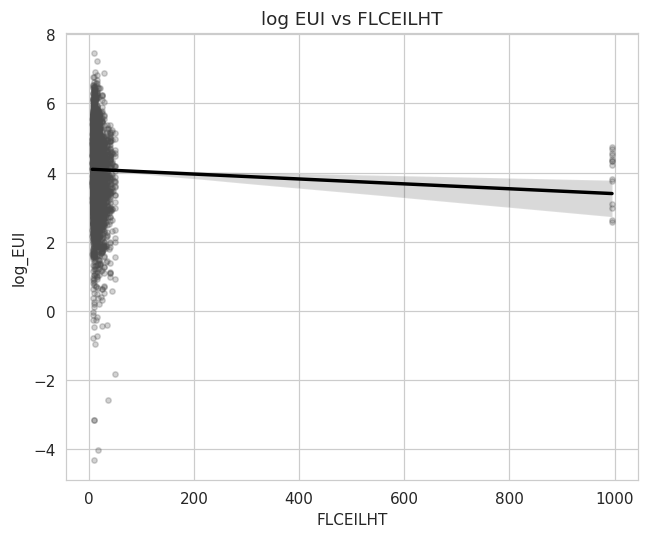

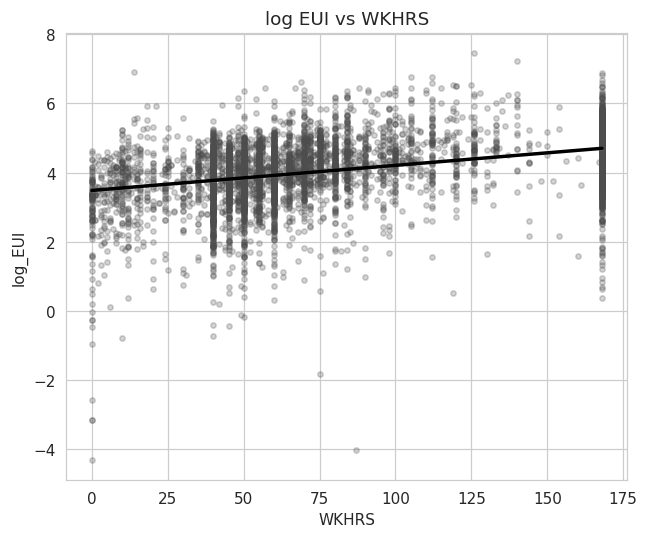

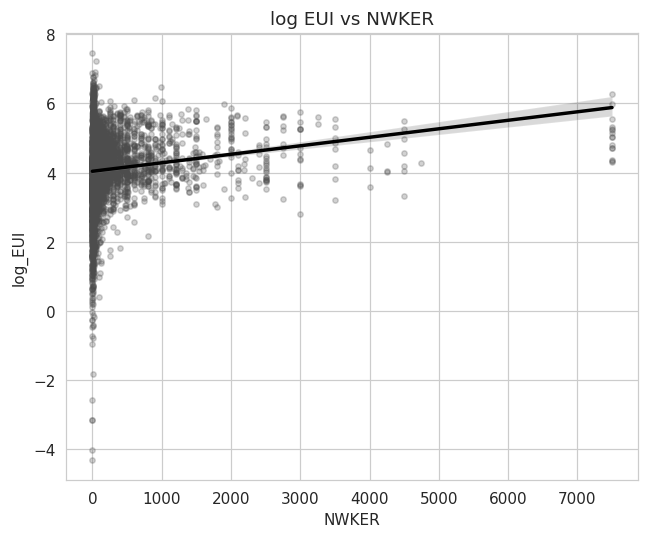

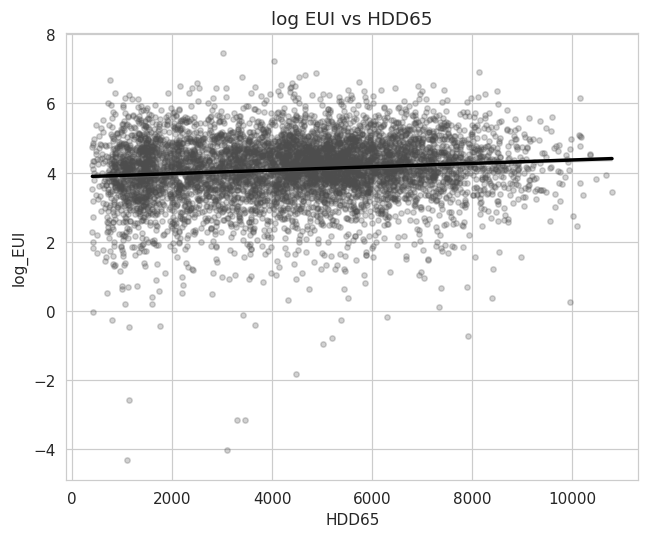

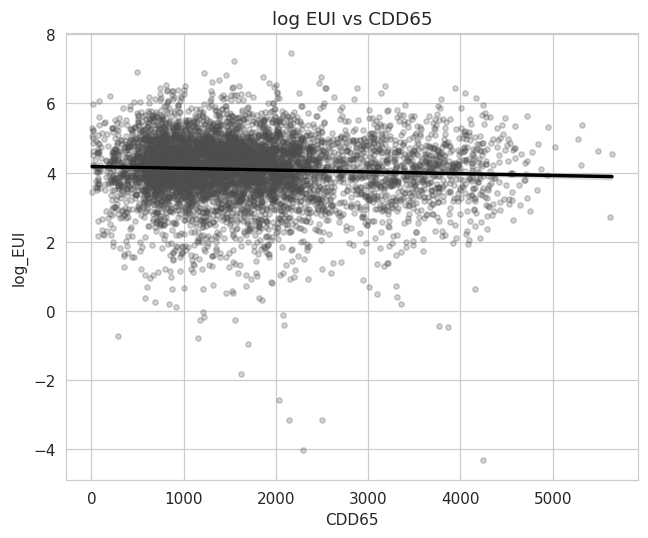

In [21]:
for col in CONTINUOUS_VARS:
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.regplot(
        data=df, x=col, y="log_EUI", ax=ax,
        scatter_kws={"alpha": 0.25, "s": 12, "color": "0.3"},
        line_kws={"color": "black"},
    )
    ax.set_title(f"log EUI vs {col}")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"06_bivariate_{col}_vs_log_EUI.png"))
    plt.show()

**Observation.** The WKHRS panel shows the clearest positive trend, consistent with its correlation, and the vertical band at 168 hours marks the continuously operating buildings. The FLCEILHT panel makes the top-code problem visible as a detached cluster at 995 pulling on the fitted line, exactly the leverage the univariate profile predicted. The remaining predictors are weak or flat at this bivariate level, which does not rule them out for RQ1, since their effects may be conditional on activity, but it does suggest no further transformation is needed beyond the log already applied to EUI.

### 5.3 Categorical Predictors vs. Log EUI

For each categorical or ordinal predictor, a boxplot of log EUI by category shows whether the group differences RQ1 and RQ2 will test are visible even before formal inference, and a survey-weighted group-mean table gives the population-level comparison rather than the unweighted one.

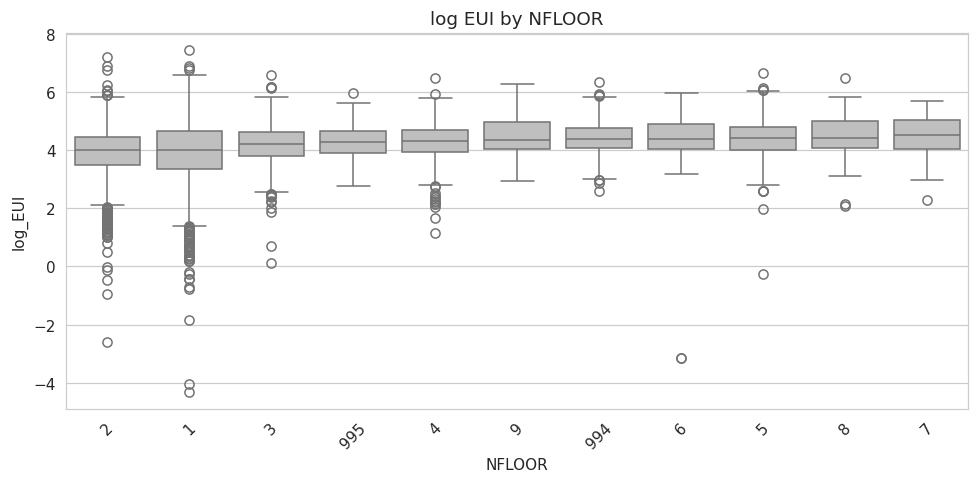

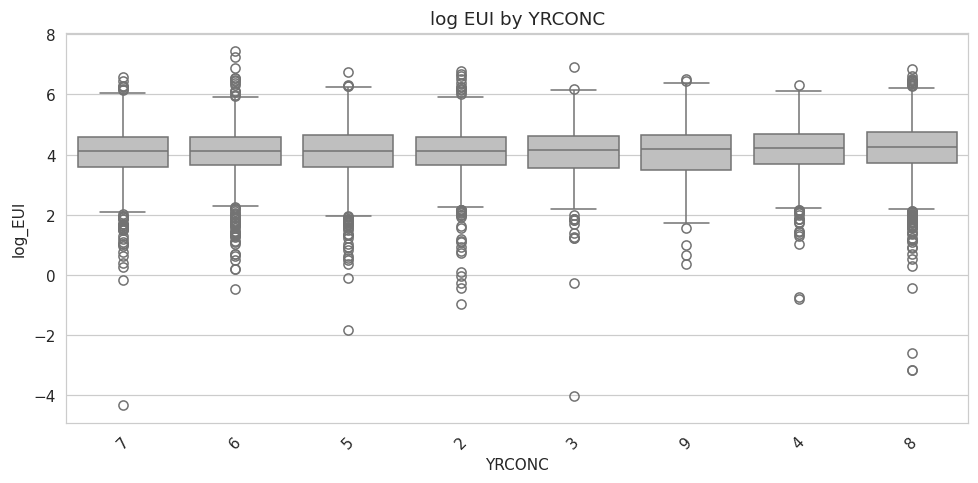

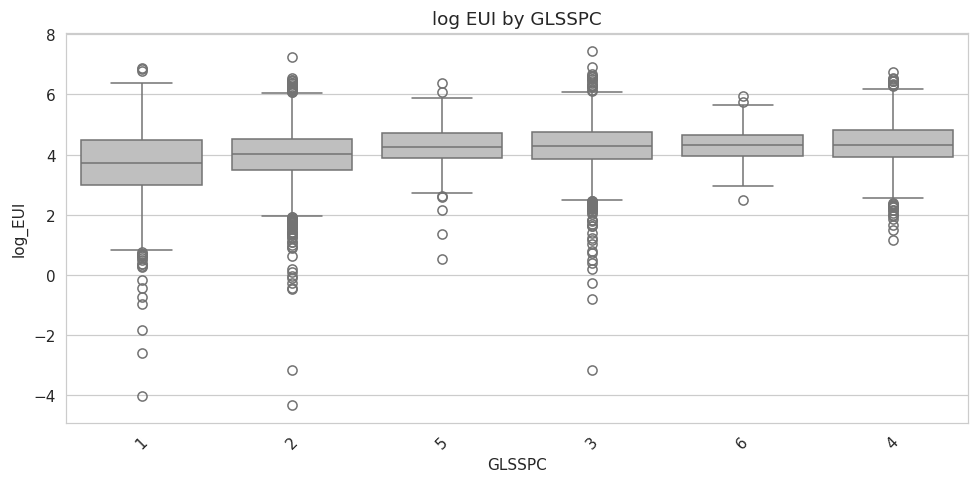

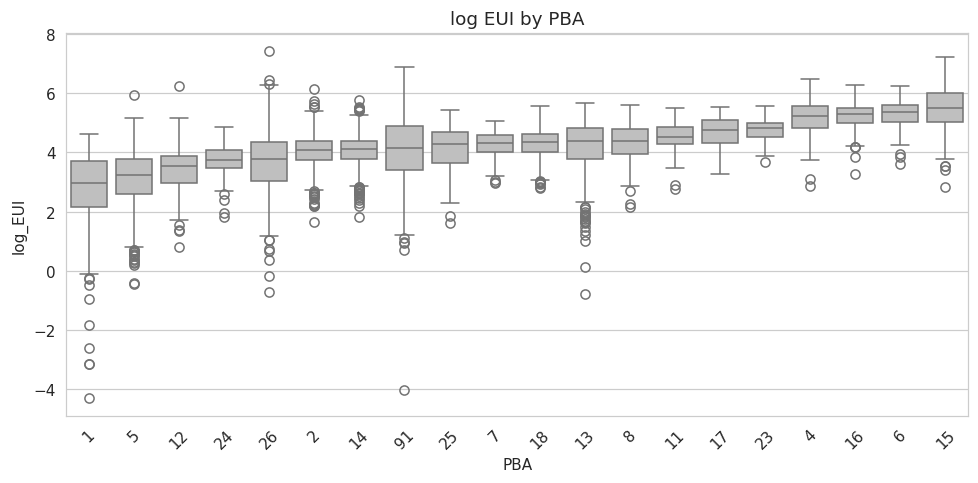

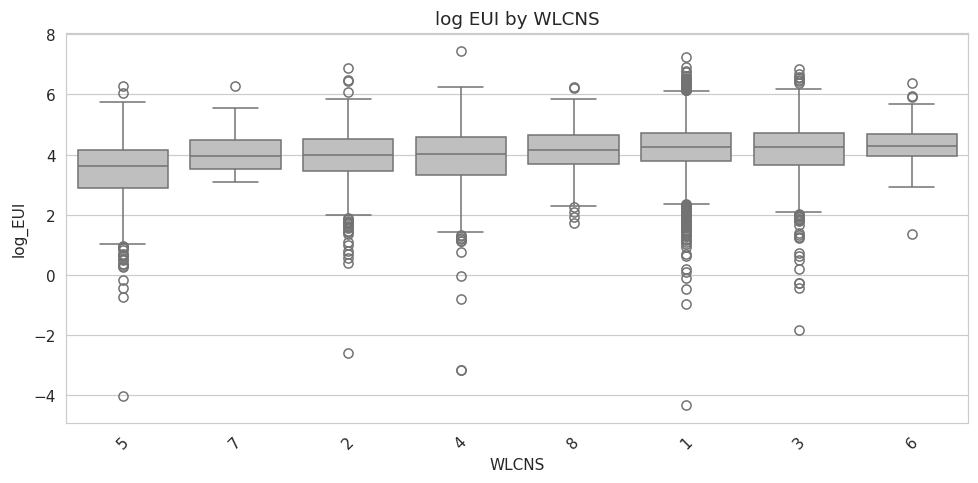

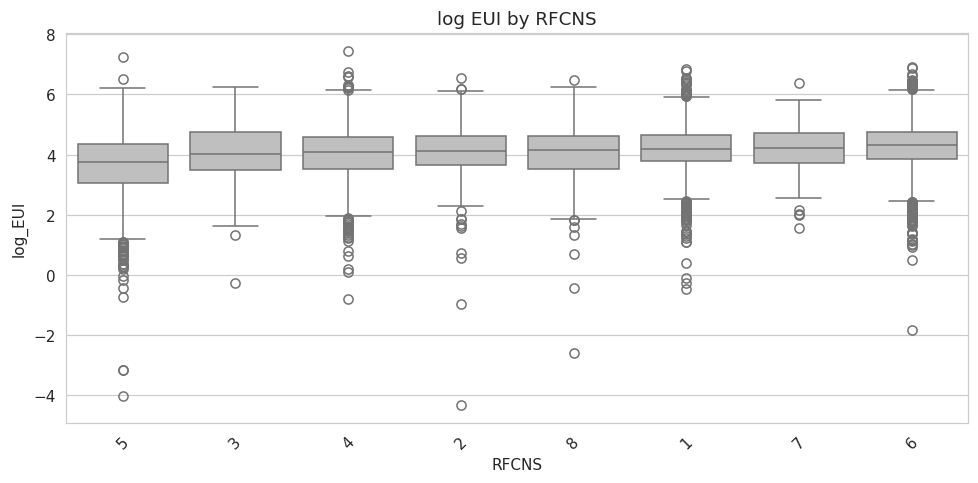

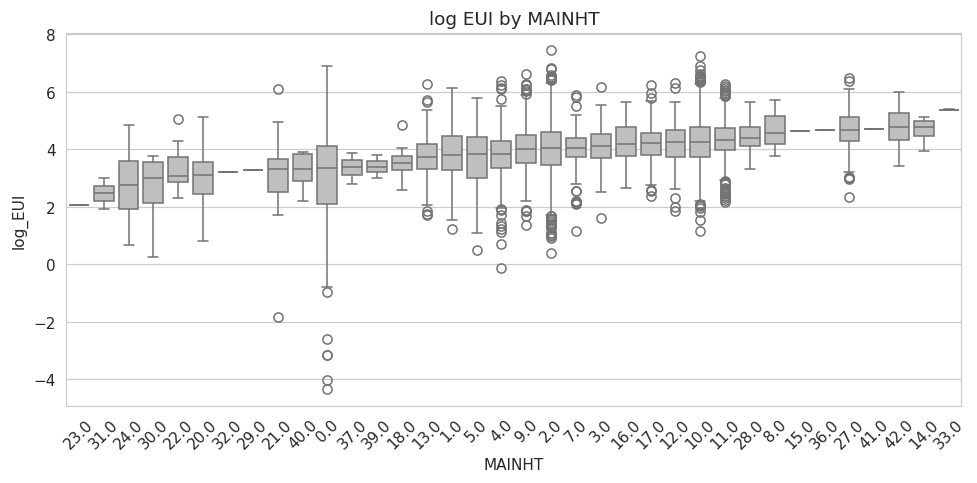

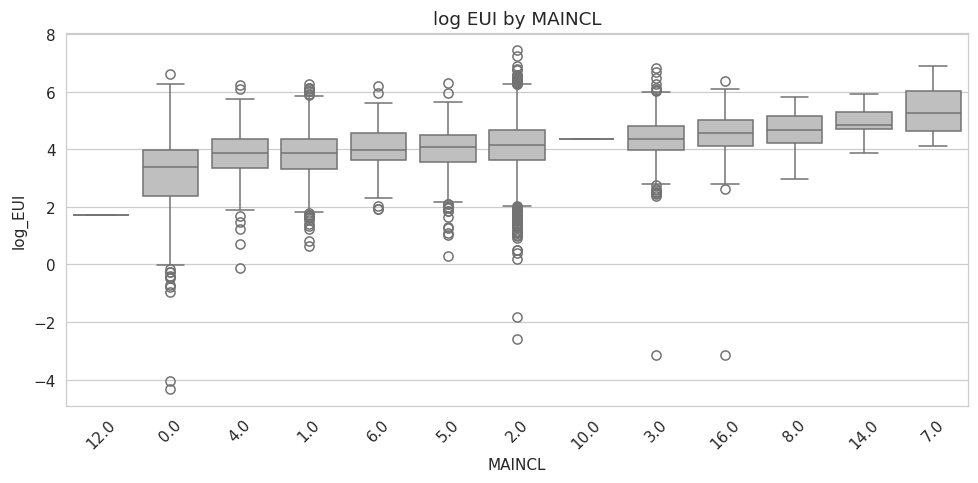

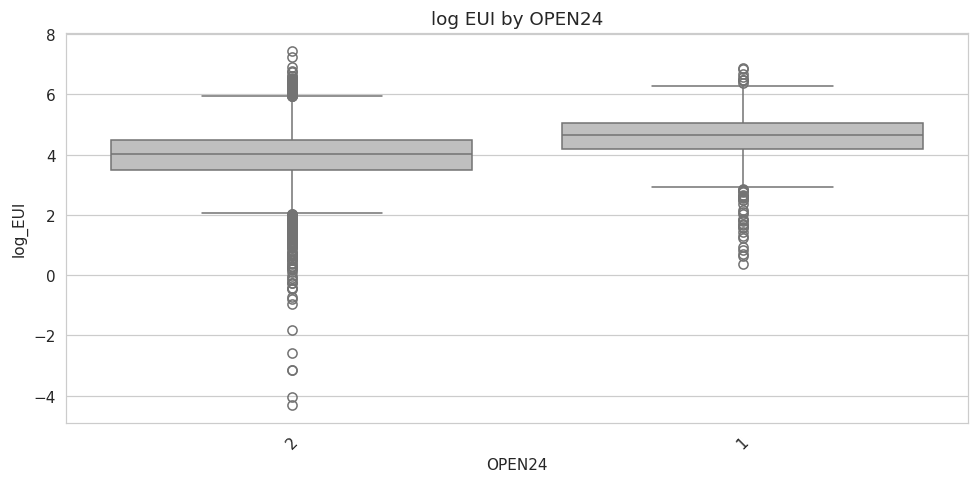

In [22]:
vars_to_profile = ORDINAL_VARS + NOMINAL_VARS

for col in vars_to_profile:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    order = df.groupby(col, observed=True)["log_EUI"].median().sort_values().index
    sns.boxplot(data=df, x=col, y="log_EUI", order=order, ax=ax, color="0.75")
    ax.set_title(f"log EUI by {col}")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"07_bivariate_{col}_vs_log_EUI.png"))
    plt.show()

    # Survey-weighted group means: np.average with FINALWT as weights,
    # since a simple groupby().mean() would give every building equal
    # weight regardless of how much of the population it represents.
    # Columns are selected before .apply() so the grouping column is not
    # passed into the lambda (avoids the pandas DeprecationWarning).
    weighted_means = (
        df.groupby(col, observed=True)[["log_EUI", WEIGHT_VAR]]
          .apply(lambda g: np.average(g["log_EUI"], weights=g[WEIGHT_VAR]))
          .rename("weighted_mean_log_EUI")
          .sort_values(ascending=False)
    )
    weighted_means.to_csv(os.path.join(TAB_DIR, f"07_weighted_group_means_{col}.csv"))

**Observation.** Activity separates buildings far more than any other categorical predictor: the survey-weighted mean log EUI spans from 5.389 for food service (code 15, roughly 219 kBtu per square foot when back-transformed) down to 2.398 for vacant buildings (code 1, roughly 11), a factor of about twenty. Food sales and inpatient health care sit near the top, warehouses and religious worship near the bottom, which matches the operational intuition that cooking, refrigeration, and round-the-clock care drive intensity. Construction vintage, by contrast, moves the weighted mean by only about 0.27 log units across cohorts, and not monotonically, an early hint that RQ2 will find vintage a real but modest effect once activity is accounted for. Buildings open 24 hours run about 0.24 log units (roughly 26 percent) above the rest, consistent with the operating-hours result above.

## 6. Export Cleaned Dataset

The cleaned analysis dataset is written alongside the figures and tables so that RQ1–RQ4 modelling notebooks can load it directly rather than repeating the cleaning steps above.

In [23]:
cleaned_path = os.path.join(TAB_DIR, "00_cleaned_analysis_dataset.csv")
df.to_csv(cleaned_path, index=False)
print(f"Cleaned sample: {len(df)} buildings written to {cleaned_path}")

Cleaned sample: 6357 buildings written to output/tables/00_cleaned_analysis_dataset.csv


---

**Committing outputs to GitHub.** From the repository root (after cloning `https://github.com/Shaman2320/QM640_Capstone_BuildingEnergyPerfromance.git`), running this notebook produces figures, tables, and the cleaned dataset under `output/`. To version-control the results alongside the notebook:

```bash
git add src/cbecs_eda_pipeline.ipynb output/
git commit -m "Add data inspection, cleaning, and EDA notebook with outputs"
git push origin main
```

Anyone with access to the repository can then pull the notebook and its saved figures and tables, or re-run the notebook (it reads the committed `data/raw/cbecs2018_final_public.csv` directly from GitHub) to reproduce them.